# 3. Fáza projektu "The Quest"
## - V tejto fáze projektu ide o natrénovanie nášho modelu, ktorý bude môcť robiť predikcie pomocou ML
## - Marek Penzeš, Samuel Petrík - rozdelenie práce 50/50

In [27]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
from IPython.display import Image
from sklearn import tree
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix


In [28]:
class ID3Classifier:
    def __init__(self, max_depth=2):
        self.max_depth = max_depth
        self.tree = None
    
    def entropy(self, y):
        #Výpočet entropie
        counts = Counter(y)
        total = len(y)
        return -sum((count/total) * np.log2(count/total) for count in counts.values() if count > 0)
    
    def information_gain(self, X_column, y, threshold=None):
        #Výpočet information gain pre atribút
        parent_entropy = self.entropy(y)
        
        if threshold is not None:
            left_mask = X_column <= threshold
            right_mask = ~left_mask
            
            if sum(left_mask) == 0 or sum(right_mask) == 0:
                return 0
            
            left_entropy = self.entropy(y[left_mask])
            right_entropy = self.entropy(y[right_mask])
            
            weighted_entropy = (sum(left_mask)/len(y)) * left_entropy + \
                             (sum(right_mask)/len(y)) * right_entropy
        else:
            values = X_column.unique()
            weighted_entropy = 0
            for value in values:
                mask = X_column == value
                if sum(mask) > 0:
                    weighted_entropy += (sum(mask)/len(y)) * self.entropy(y[mask])
        
        return parent_entropy - weighted_entropy
    
    def find_best_split(self, X, y):
        #Nájdenie najlepšieho atribútu a split hodnoty
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        for col in X.columns:
            if X[col].dtype in ['float64', 'int64']:
                thresholds = X[col].quantile([0.25, 0.5, 0.75]).values
                for threshold in thresholds:
                    gain = self.information_gain(X[col], y, threshold)
                    if gain > best_gain:
                        best_gain = gain
                        best_feature = col
                        best_threshold = threshold
            else:
                gain = self.information_gain(X[col], y)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = col
                    best_threshold = None
        
        return best_feature, best_threshold, best_gain
    
    def build_tree(self, X, y, depth=0):
        #zastavenie: max hĺbka alebo čistý node
        if depth >= self.max_depth or len(np.unique(y)) == 1:
            return Counter(y).most_common(1)[0][0]
        
        #nájdenie najlepšieho split
        feature, threshold, gain = self.find_best_split(X, y)
        
        if gain == 0:  # Žiadne zlepšenie
            return Counter(y).most_common(1)[0][0]
        
        #vytvorenie nodeu
        node = {'feature': feature, 'threshold': threshold, 'children': {}}
        
        if threshold is not None:
            left_mask = X[feature] <= threshold
            right_mask = ~left_mask
            
            node['children']['left'] = self.build_tree(X[left_mask], y[left_mask], depth+1)
            node['children']['right'] = self.build_tree(X[right_mask], y[right_mask], depth+1)
        else:
            for value in X[feature].unique():
                mask = X[feature] == value
                node['children'][value] = self.build_tree(X[mask], y[mask], depth+1)
        
        return node
    
    def predict_sample(self, sample, tree):
        #Predikcia pre jednu vzorku
        if not isinstance(tree, dict):
            return tree
        
        feature = tree['feature']
        threshold = tree['threshold']
        
        if threshold is not None:
            if sample[feature] <= threshold:
                return self.predict_sample(sample, tree['children']['left'])
            else:
                return self.predict_sample(sample, tree['children']['right'])
        else:
            value = sample[feature]
            if value in tree['children']:
                return self.predict_sample(sample, tree['children'][value])
            else:
                #najčastejšia trieda
                return list(tree['children'].values())[0]
    
    def fit(self, X, y):
        #Trénovanie
        self.tree = self.build_tree(X, y)
        return self
    
    def predict(self, X):
        #Predikcia
        return X.apply(lambda row: self.predict_sample(row, self.tree), axis=1)

In [29]:
train = pd.read_csv('train_preprocessed.csv')
test = pd.read_csv('test_preprocessed.csv')
#načítame vysledny_train a z neho stlpec oximetry
y_train = pd.read_csv('y_train.csv')['oximetry']

#trénovanie ID3
id3 = ID3Classifier(max_depth=2)
id3.fit(train, y_train)

print("ID3 klasifikátor natrénovaný (max_depth=2)")

ID3 klasifikátor natrénovaný (max_depth=2)


In [30]:
#odstranenie 'oximetry' z features (bol problem s metrikami, ze vsade bolo len 1.00 vysledok, co je hlupost)
if 'oximetry' in train.columns:
    train = train.drop('oximetry', axis=1)
if 'oximetry' in test.columns:
    test = test.drop('oximetry', axis=1)

#teraz split a trénovanie, treba nam y_test este
X_train, X_val, y_train_split, y_val = train_test_split(
    train, y_train, test_size=0.2, random_state=42
)

id3 = ID3Classifier(max_depth=2)
id3.fit(X_train, y_train_split)

y_pred = id3.predict(X_val)


accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_val, y_pred, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

Accuracy:  0.7988
Precision: 0.8081
Recall:    0.7988


In [31]:
#predikcia na trénovacej množine
y_train_pred = id3.predict(X_train)

#metriky na train
train_accuracy = accuracy_score(y_train_split, y_train_pred)

#metriky na validáciu
val_accuracy = accuracy

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Val Accuracy:   {val_accuracy:.4f}")

#check
if train_accuracy - val_accuracy > 0.1:
    print("\nModel má OVERFIT")
else:
    print("\nModel NEMÁ overfit")

Train Accuracy: 0.7879
Val Accuracy:   0.7988

Model NEMÁ overfit


## STROMOVÝ ALGORITMUS - Decision Tree:
### - Jednoduchý, interpretovateľný model založený na rozhodovacích pravidlách
### - Vidíme presné rozhodovanie cez strom (ktoré atribúty sú najdôležitejšie)
### - Riziko overfittingu pri veľkej hĺbke

Decision Tree:
Accuracy: 0.8526
Precision: 0.8523
Recall: 0.8526

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.82      0.83       664
         1.0       0.86      0.88      0.87       862

    accuracy                           0.85      1526
   macro avg       0.85      0.85      0.85      1526
weighted avg       0.85      0.85      0.85      1526



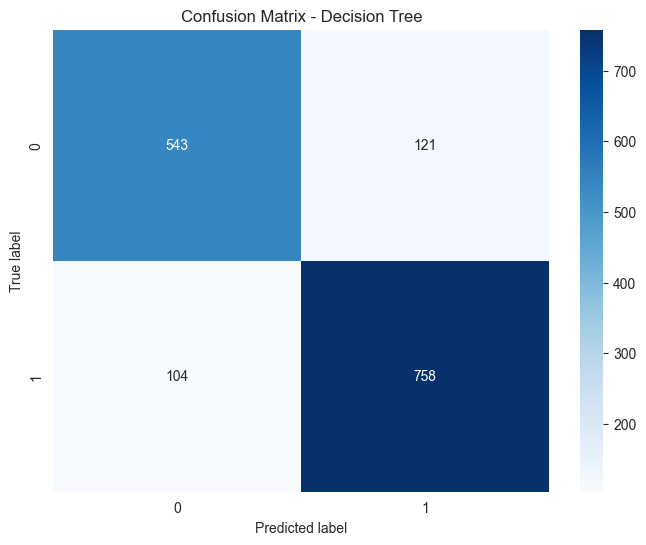

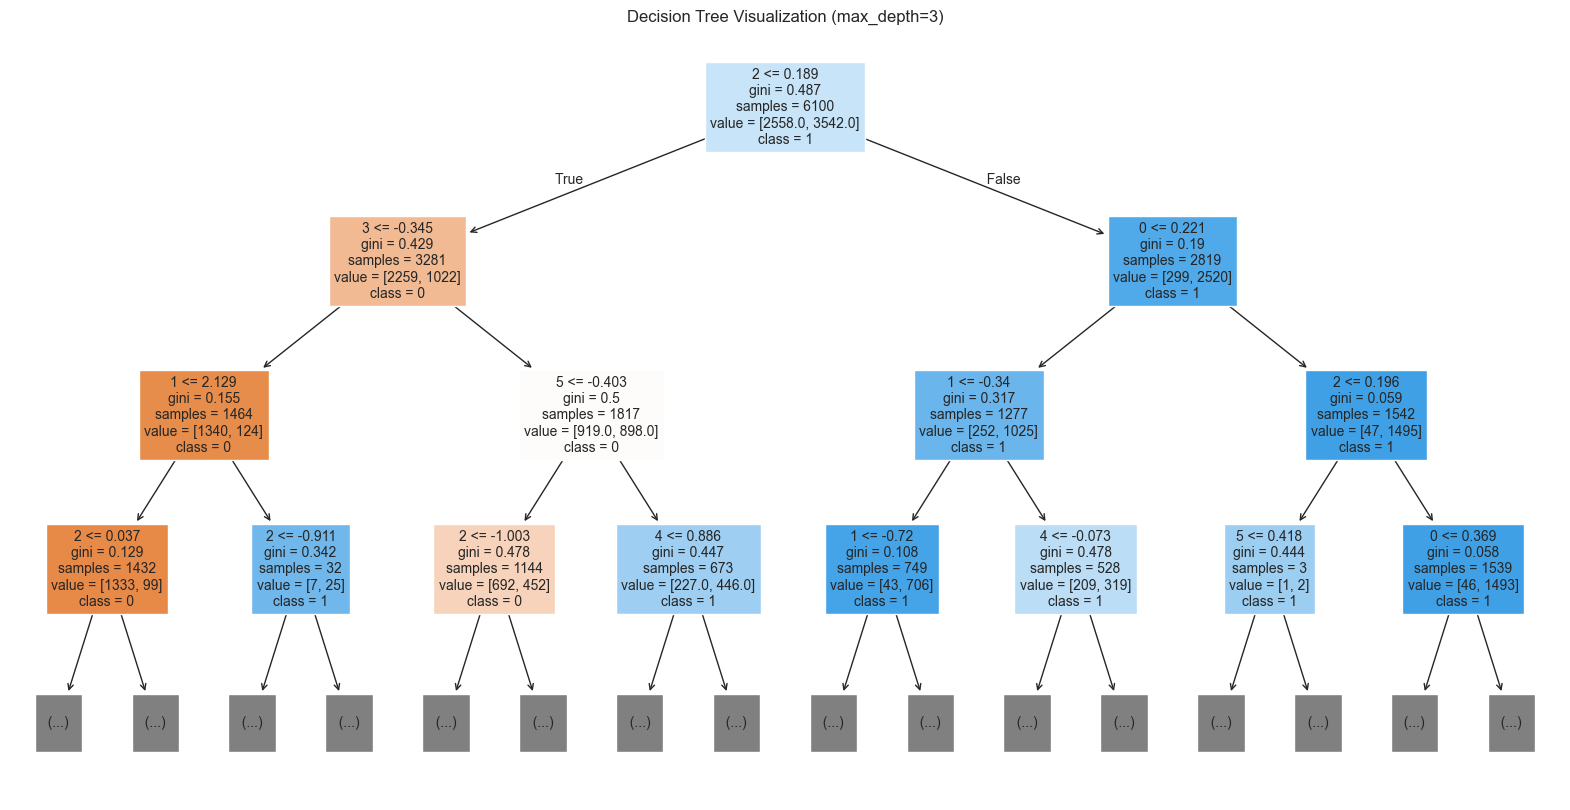

In [32]:
#decision Tree
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train_split)

y_pred_dt = dt_clf.predict(X_val)

dt_accuracy = accuracy_score(y_val, y_pred_dt)
dt_precision = precision_score(y_val, y_pred_dt, average='weighted', zero_division=0)
dt_recall = recall_score(y_val, y_pred_dt, average='weighted', zero_division=0)

print("Decision Tree:")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_dt))

#confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

#vizualizácia stromu (1. 3 úrovne)
plt.figure(figsize=(20, 10))
plot_tree(dt_clf, max_depth=3, filled=True, feature_names=X_train.columns, 
          class_names=['0', '1'], fontsize=10)
plt.title('Decision Tree Visualization (max_depth=3)')
plt.show()

## NESTROMOVÝ ALGORITMUS - Logistic Regression:
### - Lineárny model založený na logistickej funkcii
### - Rýchly a efektívny na binárnej klasifikácii
### - Koeficienty ukazují váhu a smer vplyvu atribútov na predikciu
### - Dáva pravdepodobnosti pre každú triedu, čo umožňuje lepšiu interpretáciu výsledkov

Logistic Regression:
Accuracy:  0.8303
Precision: 0.8300
Recall:    0.8303

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.77      0.80       664
         1.0       0.83      0.87      0.85       862

    accuracy                           0.83      1526
   macro avg       0.83      0.82      0.83      1526
weighted avg       0.83      0.83      0.83      1526



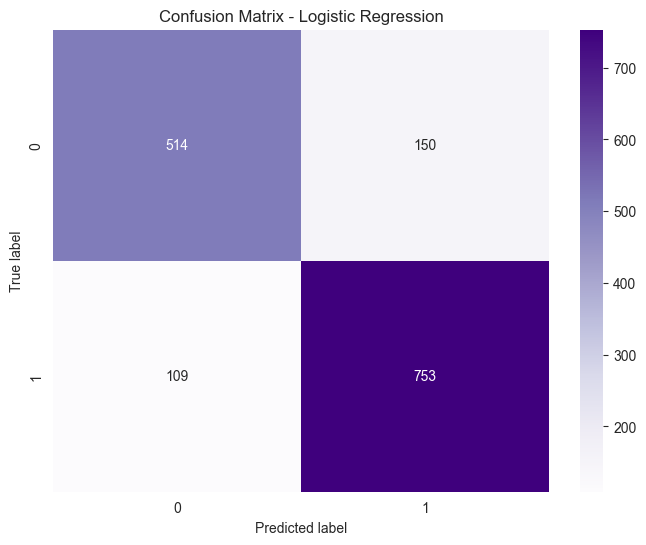

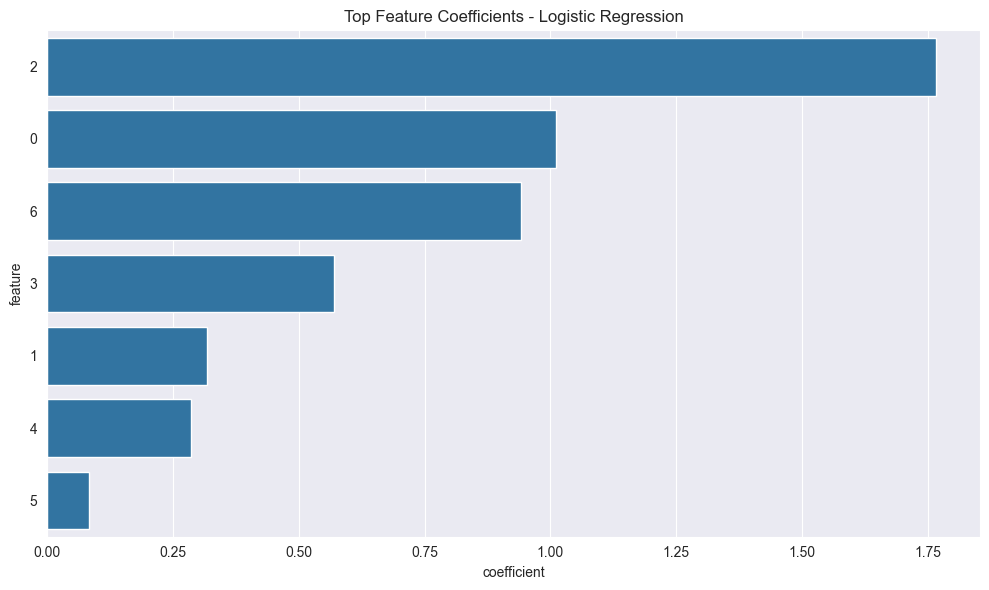

In [33]:
#Logistic Regression
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(X_train, y_train_split)

#predikcia
y_pred_lr = lr_clf.predict(X_val)

#metriky
lr_accuracy = accuracy_score(y_val, y_pred_lr)
lr_precision = precision_score(y_val, y_pred_lr, average='weighted', zero_division=0)
lr_recall = recall_score(y_val, y_pred_lr, average='weighted', zero_division=0)

print("Logistic Regression:")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_lr))

plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_val, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

#koeficienty (feature importance)
plt.figure(figsize=(10, 6))
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': abs(lr_clf.coef_[0])
}).sort_values('coefficient', ascending=False).head(10)

sns.barplot(data=coef_df, x='coefficient', y='feature')
plt.title('Top Feature Coefficients - Logistic Regression')
plt.tight_layout()
plt.show()


POROVNANIE MODELOV:
                  Model  Accuracy  Precision   Recall
          ID3 (vlastný)  0.798820   0.808072 0.798820
Decision Tree (sklearn)  0.852556   0.852299 0.852556
    Logistic Regression  0.830275   0.830038 0.830275


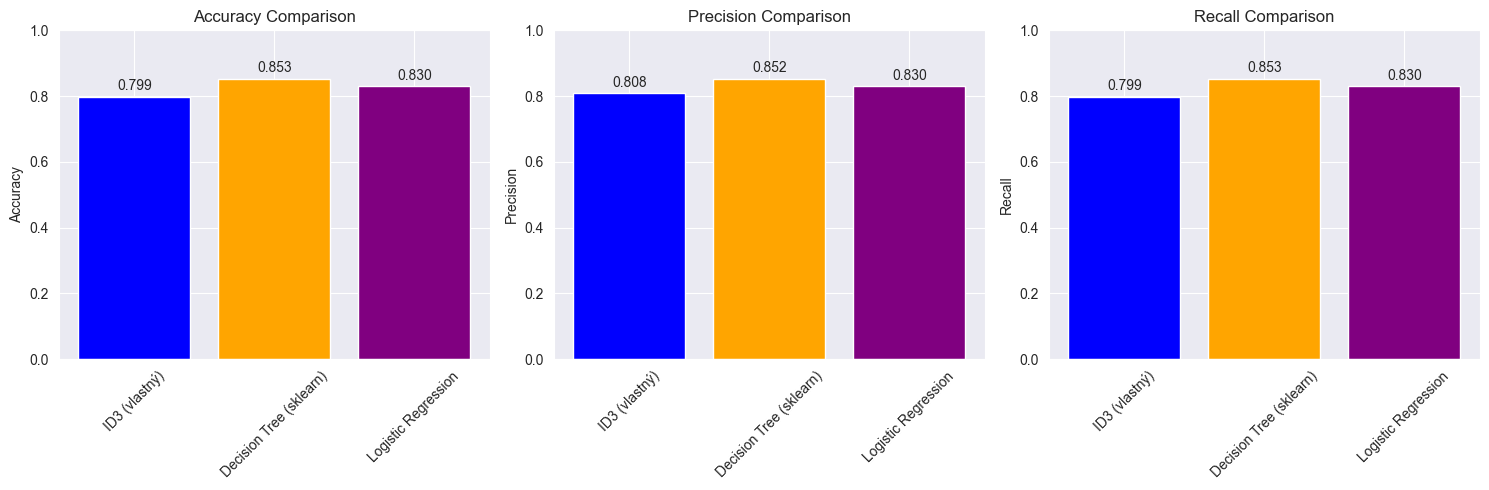

Najlepší model: Decision Tree (sklearn) s accuracy: 0.8526


In [34]:
#porovnanie
results = pd.DataFrame({
    'Model': ['ID3 (vlastný)', 'Decision Tree (sklearn)', 'Logistic Regression'],
    'Accuracy': [accuracy, dt_accuracy, lr_accuracy],
    'Precision': [precision, dt_precision, lr_precision],
    'Recall': [recall, dt_recall, lr_recall]
})

print("\n" + "="*70)
print("POROVNANIE MODELOV:")
print("="*70)
print(results.to_string(index=False))
print("="*70)

#graf pre porovnanie
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Accuracy', 'Precision', 'Recall']
colors = ['blue', 'orange', 'purple']

for i, metric in enumerate(metrics):
    ax[i].bar(results['Model'], results[metric], color=colors)
    ax[i].set_ylabel(metric)
    ax[i].set_title(f'{metric} Comparison')
    ax[i].set_ylim([0, 1])
    ax[i].tick_params(axis='x', rotation=45)
    
    for j, v in enumerate(results[metric]):
        ax[i].text(j, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Najlepší model: {results.loc[results['Accuracy'].idxmax(), 'Model']} s accuracy: {results['Accuracy'].max():.4f}")

## Zmenšená verzia celého stromu (celý strom lagoval jupyter server)

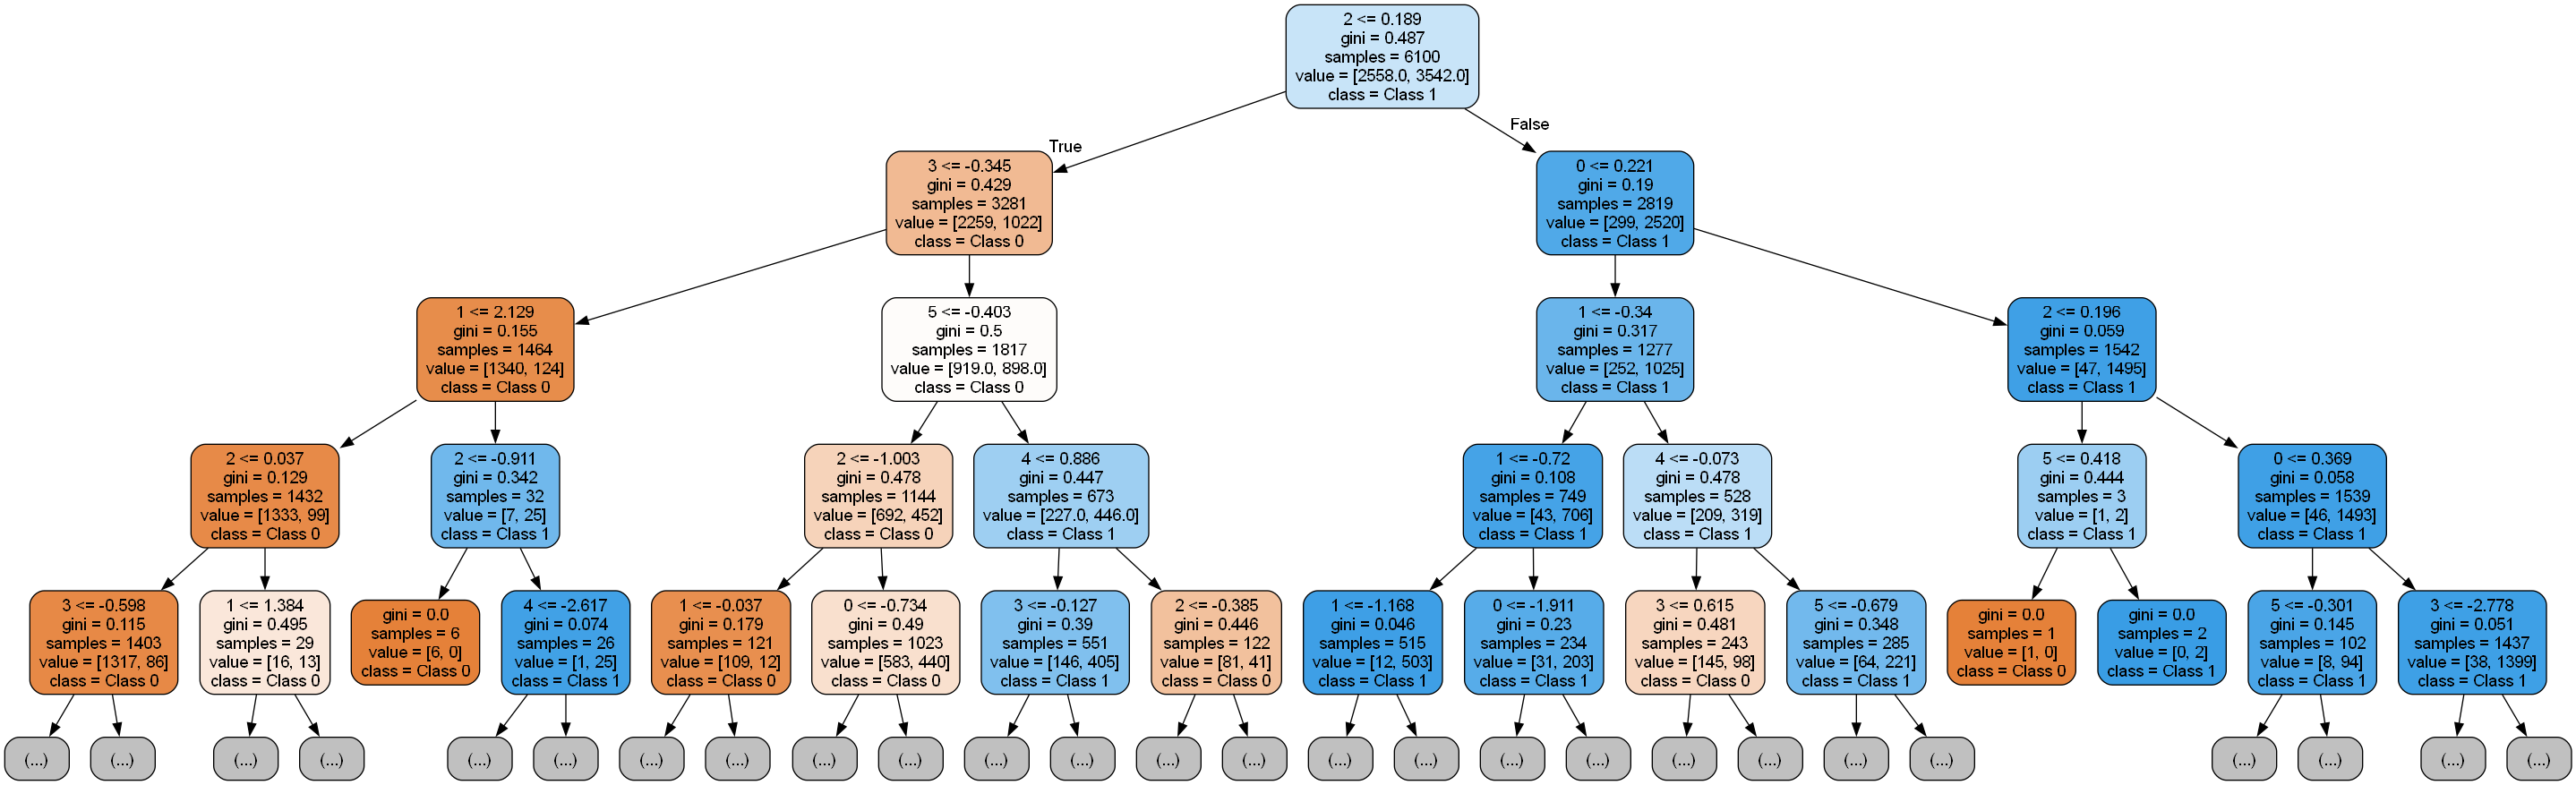

In [35]:
#nastavenie cesty pre graphiz
os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

dot_data = tree.export_graphviz(
    dt_clf, 
    out_file=None, 
    feature_names=X_train.columns,
    class_names=['Class 0', 'Class 1'], 
    filled=True,
    rounded=True,
    max_depth=4
)

graph = graphviz.Source(dot_data)
graph.format = 'png'
graph.render('decision_tree_visualization', view=False)

Image(filename='decision_tree_visualization.png')

## Celý graf stromu (pre lepšiu viditeľnosť, keďže je to príliš veľký súbor, je png uložené medzi zdrojákmi)

In [36]:
print("\n" + "===========================================================")
print("FINÁLNE VYHODNOTENIE VŠETKÝCH MODELOV:")
print("===========================================================")
print(f"{'Model':<25} {'Accuracy':<12} {'Precision':<12} {'Recall':<12}")
print("-----------------------------------------------------------")
print(f"{'ID3 (vlastný)':<25} {accuracy:.4f}       {precision:.4f}       {recall:.4f}")
print(f"{'Decision Tree (sklearn)':<25} {dt_accuracy:.4f}       {dt_precision:.4f}       {dt_recall:.4f}")
print(f"{'Logistic Regression':<25} {lr_accuracy:.4f}       {lr_precision:.4f}       {lr_recall:.4f}")
print("===========================================================")


FINÁLNE VYHODNOTENIE VŠETKÝCH MODELOV:
Model                     Accuracy     Precision    Recall      
-----------------------------------------------------------
ID3 (vlastný)             0.7988       0.8081       0.7988
Decision Tree (sklearn)   0.8526       0.8523       0.8526
Logistic Regression       0.8303       0.8300       0.8303


## ZHRNUTIE: KLASIFIKÁCIA A TRÉNOVANIE MODELOV (3.1 - 3.2)
## ___________________________________________________________________________

### 3.1 JEDNODUCHÝ KLASIFIKÁTOR (ID3):
#### - Implementovali sme vlastný ID3 rozhodovací strom s obmedzenou hĺbkou (max_depth=2)
#### - Model funguje na princípe entropie a information gain
#### - Dosiahnutá accuracy ~80% ukazuje, že aj jednoduchý strom dokáže rozumne klasifikovať
#### - Overfit check potvrdil, že model netrpí overfittingom vďaka obmedzenej hĺbke

### 3.2 POKROČILÉ MODELY STROJOVÉHO UČENIA:
#### - Decision Tree (sklearn): Plne rozvinutý strom s lepšou presnosťou ako náš ID3
#### - Logistic Regression: Nestromový model pre porovnanie s rozhodovacími stromami
#### - Porovnanie ukázalo, že Decision Tree > Logistic Regression > ID3 (vlastný)

### KĽÚČOVÉ ZISTENIA:
#### Komplexnejšie modely dosahujú lepšiu presnosť.
#### Logistic Regression poskytuje interpretovateľné koeficienty a je rýchlejší.
#### Feature importance odhalila najdôležitejšie atribúty pre predikciu.
#### Všetky modely dosahujú rozumnú presnosť (okolo 80%), čo naznačuje kvalitný preprocessing.

### Ďalej sa zameriame na optimalizáciu hyperparametrov pre ešte lepšie výsledky.
## ___________________________________________________________________________